## Çok sınıflı sınıflandırma (Multiclass classification)

* Önceki görevde ikili (binary) bir sınıflandırma problemini çözdük.  
* Peki ya **çok sınıflı (multiclass) bir sınıflandırma problemi**?

🎯 Egzersizin Amaçları:
- Çok sınıflı bir sınıflandırma problemi için tasarlanmış bir Sinir Ağı (Neural Network) yazmak
- Bu modelin ne kadar kolay **overfit** olabileceğini gözlemlemek… !

## (1) Bir `Blobs` veri kümesi oluşturun

📚 Sklearn’deki **`make_blobs`** fonksiyonu [(dokümantasyona bakınız)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) aşağıdakileri üretmenize olanak tanır:
- İstenilen sayıda veri örneği (`n_samples` parametresi)
- Her veri örneği için istenilen sayıda özellik (`n_features` parametresi)
- İstenilen sayıda sınıf/kategori (`centers` parametresi)
- Sınıflar arasındaki mesafe (`cluster_std` parametresi)

💡 Ayrıca, verinin **deterministik** olarak (aynı şekilde) üretilmesini ve tekrar edilebilir olmasını sağlayan `random_state` parametresi de vardır.


❓ Belgelere göre:

👽 Aşağıdakilerle bir ***blobs*** veri kümesi oluşturun:
- 1200 örnek
- Örnek başına 8 özellik
- 7 veri kategorisi
- Kategoriler arasındaki mesafe 8

🔮 1'e eşit bir `random_state` seçin.

📏 Şekli yazdırın ve `X` için (1200, 8) ve `y` için (1200,) ile eşleştiğini kontrol edin ❓

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1200,
    centers=7,
    n_features=8,
    cluster_std=8,
    random_state=1
)

X.shape, y.shape

((1200, 8), (1200,))

X bizim girdi özelliklerimiz. 1200 satırımız var ve her satırda 8 özellik bulunuyor. y ise her satırın ait olduğu sınıf etiketi; bu kez iki sınıf değil 7 farklı sınıf var. 
random_state=1 aynı senteetik veris etini tekrar üretmemizi sağlar. İlk alıştırmada gördüğümüz aynı ayarlar farklı sonuç durumunu burada bu parametre ile sabitlemiş oluyoruz. 

❓ _matplotlib_ kullanarak bu blob veri kümesinin iki (rastgele) boyutunun dağılım grafiğini çizin. Her nokta, ait olduğu kategoriye göre renklendirilmelidir. ❓

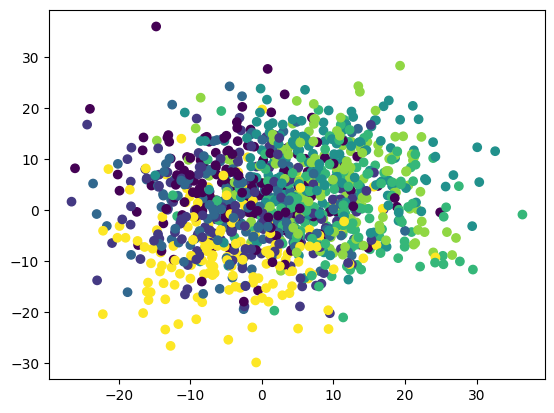

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

# 0. boyut ile 1. boyutu gösterme
plt.scatter(X.T[0], X.T[1], c=y)
plt.show()

❓ Diğer boyutlarda da aynı işlemi tekrarlayın. Veri noktalarının kolayca ayrılmadığını görsel olarak görebilirsiniz ❓

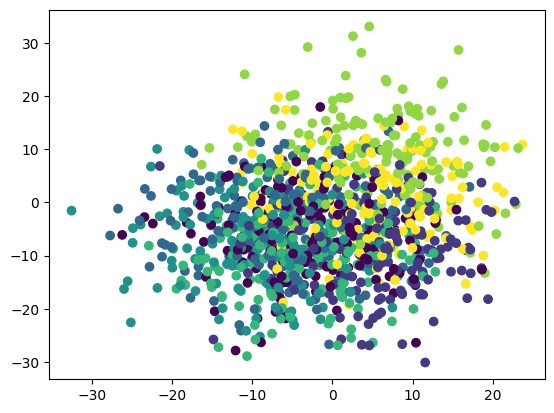

In [3]:
plt.scatter(X.T[3], X.T[6], c=y)
plt.show()

Veri 8 boyutlu. İki feature'ı seçip 2D grafiğe baktığımızda sınıflar kolayca ayrışmıyor. Ancak bu, 8 feature birlikte kullanıldığında sınıfların ayrılamayacağı anlamına gelmez. Model tüm featurelar'ı birlikte değerlendirecek.

## (2) Çok sınıflı sınıflandırma probleminin hedefini kodlama

👉 Şu an için hedef `y`, giriş verisinin ait olduğu kategoriyi temsil eden **tamsayılar listesidir**. Şöyle görünür:  
`[3, 2, 2, 3, 0, 5, 1, 1, 0, 5, ...]`  
(bu örnekte 0’dan 6’ya kadar **7 kategori** vardır).

🧑🏻‍🏫 Ancak **Tensorflow/Keras’ta kategorik problemler için hedef/çıktı (`target/output`) aşağıdaki şekilde encode edilmelidir**:

```
[
[0, 0, 0, 1, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[1, 0, 0, 0, 0, 0, 0], 
[0, 0, 0, 0, 0, 1, 0], 
[0, 1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1],
...
]
```


Burada:
- satır sayısı, **gözlem sayısına** eşittir  
- sütun sayısı, **farklı kategori sayısına** eşittir  

👉 Her sütun bir **kategoriyi** temsil eder.  

👉 Her satır bir **hedefi** temsil eder; `1` değeri, giriş verisinin ait olduğu kategoriyi gösterir.  

Bir satırı, olasılık vektörü olarak düşünebilirsiniz.

```
Örnek:
| Cat 0 | Cat 1 | Cat 2 | Cat 3 | Cat 4 | Cat 5 | Cat 6 |
|-------|-------|-------|-------|-------|-------|-------|
| 0     | 0     | 0     | 1     | 0     | 0     | 0     |

Bu, ilgili satırın %100 olasılıkla Cat 3’e ait olduğu anlamına gelir.
Cat 3
```


---

💡 `y`’yi kategorik hale dönüştürmek için **Tensorflow/Keras içindeki `to_categorical`** fonksiyonunu kullanın.

<details>
    <summary><i>Tensorflow/Keras’taki <code>to_categorical</code> ile Scikit-Learn’deki <code>OneHotEncoder</code> arasında bir benzerlik var mı?</i></summary>

Evet! **`to_categorical`**, Sklearn’deki `OneHotEncoder` gibi çalışır;  
ancak burada bir **kategorik feature** değil, **kategorik target (hedef)** encode edilir.

</details>

---

❓ **Kategorik hedefin kodlanması**:  `y` yazdırın, ardından *to_categorical* işlevini *`y`* üzerinde uygulayın ve *y'nin kategorize edilmiş halini* `y_cat` adlı bir değişkene kaydedin. ❓

In [4]:
from keras.utils import to_categorical

print("-"*50)
print("Orijinal hedef şu şekilde görünür:")
print(y)

print("Şekli:")
print(y.shape)

print("-"*50)

print("Kodlanmış hedef şu şekilde görünür:")
y_cat = to_categorical(y)
print(y_cat)

print("Şekli:")
print(y_cat.shape)

2026-09-13 20:55:15.575910: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-13 20:55:16.364113: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-13 20:55:17.211115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-13 20:55:17.879425: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-13 20:55:17.882542: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-13 20:55:19.181955: I tensorflow/core/platform/cpu_feature_guard.cc:

--------------------------------------------------
Orijinal hedef şu şekilde görünür:
[2 2 5 ... 1 3 0]
Şekli:
(1200,)
--------------------------------------------------
Kodlanmış hedef şu şekilde görünür:
[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
Şekli:
(1200, 7)


## (3) Çok Sınıflı Sınıflandırma Görevi için Sinir Ağı

❓ **Hold-out yöntemi**: Veri kümesi $X$ ve $y_{cat}$ 'i _train_ ve _test_ kümelerine ayırın (boyut: 70/30%)

Not: Değişkenleri `X_train`, `X_test`, `y_train` ve `y_test` olarak adlandırın ❓

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.3)

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((840, 8), (360, 8), (840, 7), (360, 7))

In [7]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(840, 8) (360, 8)
(840, 7) (360, 7)


Veri > ağ mimarisi
8 feature > sinir ağı > 7 sınıf

1200 adet, 8 özellikli gözlemimiz var; bunları 7 sınıftan birine sınıflandırmayı öğreteceğiz. 840 tanesiyle modeli eğitip, hiç görmediği 360 tanesiyle gerçekten öğrenip öğrenmediğini sınayacağız.

Derin Öğrenmede, herhangi bir Makine Öğrenimi algoritmasında olduğu gibi, sayısal özellikleriniz ölçeklendirilmelidir.

❓ **Ölçeklendirme**: Eğitim kümesine bir Sklearn [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) uydurun ve hem eğitim kümenizi hem de test kümenizi dönüştürün ❓

In [8]:
from sklearn.preprocessing import StandardScaler

s_scaler = StandardScaler()
s_scaler.fit(X_train)

X_train = s_scaler.transform(X_train)
X_test = s_scaler.transform(X_test)

❓ **Modeli başlatma**: Aşağıdaki işlevi tamamlayarak aşağıdaki özelliklere sahip bir model oluşturun/başlatın:
- İlk katman:
   - 50 nöron
   - `relu` aktivasyonu
   - Doğru giriş boyutu
- Çıkış katmanı:
   - Çok sınıflı sınıflandırma görevi için tasarlanmış
   - Her sınıfa ait olma olasılıklarını çıktı olarak veren ❓

In [9]:
from keras import Sequential, Input, layers

In [ ]:
def initialize_model():

    #############################
    #  1 - Model mimarisi       #
    #############################

 
    model = Sequential()
    model.add(Input(shape=(8,)))
    model.add(layers.Dense(50, activation='relu'))
    model.add(layers.Dense(7, activation='softmax'))


    #############################
    #  2 - Optimizasyon Yöntemi #
    #############################
    model.compile(loss='categorical_crossentropy', # binary_crossentropy'den farklı çünkü çoklu sınıfımız var
                  optimizer='adam',
                  metrics=['accuracy'])

    return model


model = initialize_model()

❓  Modelde kaç parametre (diğer adıyla ağırlık) vardır? ❓

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓ **Modeli uydurma**: Modelinizi 50 dönemlik tren verilerine uydurun ve geçmişi çizin ❓

In [23]:
model = initialize_model()

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    verbose=0)

❓ **Değerlendirme**:  Modelinizi test setinde değerlendirin ve doğruluğu yazdırın ❓

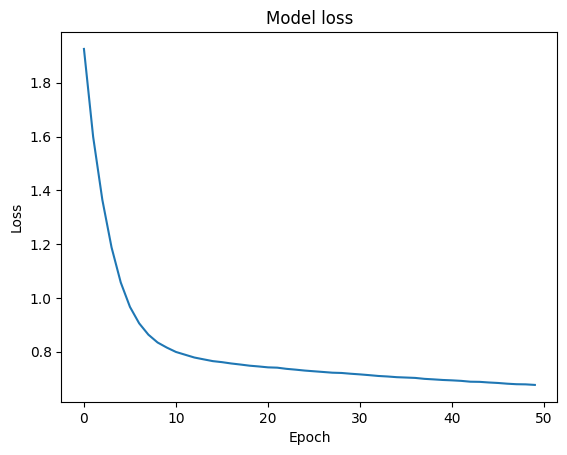

In [24]:
def plot_history(history):
    plt.plot(history.history['loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.show()

plot_history(history)

❓ 🤔 Bu iyi bir puan mı? Bunu bir tür karşılaştırma değeriyle karşılaştırmalısınız. Bu durumda, rastgele bir tahminle ne kadar puan elde edilebilir? Bu temel puanı `accuracy_baseline` değişkeninde saklayın. ❓

(Bunun için kod yazmanıza gerek yok, sadece veri setimizin nasıl oluşturulduğunu düşünün.)

In [25]:
results = model.evaluate(X_test, y_test, verbose=0)
print(results[1])

0.7027778029441833


In [26]:
accuracy_baseline = None

In [27]:
accuracy_baseline = 1/7

🧪 **Kodunu Test Et**

In [28]:
from nbresult import ChallengeResult
result = ChallengeResult('baseline',
                         accuracy=accuracy_baseline)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/benal/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/benal/workintech/S18D2-S-Data-multiclass-classification/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline.py::TestBaseline::test_accuracy PASSED                     [100%]

============================== 1 passed in 0.09s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



Başlangıçta make_blobs ile 1200 gözlem, 8 özellik ve 7 farklı sınıftan oluşan bir veri seti yarattık.
Sonra y'yi one hot encoging yaptık. Örnek olarak sınıf 2, [0, 0, 1, 0, 0, 0, 0] haline geldi. Bunun nedeni çıkış katmanımızda 7 nöron bulunması ve her nöronun bir sınıfı temsil etmesi.
Ardından veriyi %70 train / %30 test ayırdık. Yani model 840 örnekten öğreniyor, hiç görmediği 360 örnekle sınava giriyor. 
Sonra StandardScaler ile X'leri ölçekledik. TRAIN > fit + transform | TEST > sadece transform (Test setinden bilgi öğrenmedik)
Kurduğumuz sinir ağı ise;
8 özellik > 50 nöron + ReLU > 7 nöron + Softmax > 7 sınıfın olasılıkları 
Yani softmax nedeniyle model tek bir sayı üretmiyor. Örneğin [0.03, 0.05, 0.70, 0.04, 0.06, 0.07, 0.05] 
Bu örneğin %70 ihtimalle sınıf 2 olduğunu düşünüyorum der model.
Sonra modeli eğittik; "840 eğitimin örneğini kullan, 16şarlı gruplar halinde işle ve tüm eğitim setinin üzerinden 50 kez geç. Loss gitgide düşüyor. Yani model öğreniyor ve yakınsıyor (convergence). BAşlangıçta ızlı öğreniyor, ileleyen epoch'larda eğri yataylaşıyor. Model hala gelişiyor ama her ek epoch un kazancı giderek küçülüyor. 
Sonra modeli hiç görmediği test verisine soktuk. Hiç görmediği 360 örneğin yaklaşık %70,3'ünü doğru sınıflandırdı. 
Peki %70 iyi mi? Karar vermek için buna bir baseline lazım. Base line belirlemek için şunu düşündük, bizim 7 sınıfımız var ve veri oluşturulurken sınıflar dengeli. Rastgele sınıf seçen bir modelin başarı olasılığı 1/7 yani %14,3. Yani rastgele tahmin %14,3, modelin yani kuguladığımız sinir ağı tahmini %70,3. Model rastgele tahminden çok daha iyi.

❗ 👀 Bekle ... Kayıp grafiğine daha yakından bakarsan, 50 dönemden sonra da kayıp hala azalmaya devam ediyor gibi görünüyor. Neden bu kadar erken durduruyorsun ❓❗

❓ Modeli yeniden başlatıp bu sefer 1000 dönemle tekrar çalıştıralım ve geçmişi tekrar grafiğe çizelim. ❓

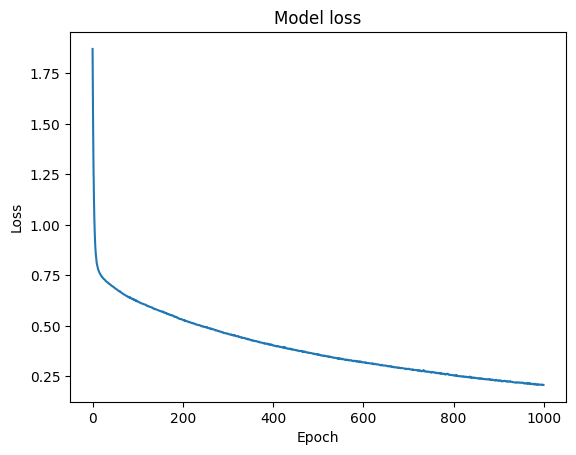

In [29]:
model = initialize_model()

history = model.fit(X_train,
                    y_train,
                    epochs=1000,
                    batch_size=16,
                    verbose=0)

plot_history(history)

❓ **Bir modeli daha uzun süre eğitirken...** ❓
- Yeni kayıp hakkında ne söyleyebilirsiniz?
- Modelinizi test setinde bir kez daha değerlendirin ve doğruluğu yazdırın.

In [30]:
results = model.evaluate(X_test, y_test, verbose=0)
print(results[1])

0.5694444179534912


Modeli daha uzun süre eğitmek onu test performansı açısından daha kötü yaptı. 1000epoch sonunda training loss, 50epoch sonucuna göre daha fazla azalmıştır. Ancak test doğruluğu %70den %50lere düşmüştür. Bu durum modelin eğitim verisine giderek daha fazla uyum sağlarken yeni veriler üzerinde genelleme yeteneğinin azaldığını yani overfitting oluştuğunu göstermektedir.

* 😁 Tren setinde hesaplanan kayıp, 50 epok ile karşılaştırıldığında 1000 epok ile daha küçük görünüyor.
* 😟 Anc ak test setindeki doğruluk, 50 epok ile karşılaştırıldığında 1000 epok ile daha kötü...

❓ Bu fenomene ne denir? ❓

AŞIRI ÖĞRENME

---

🤔 Bunun olmasını önlemek için ne yapmalıyız? 

<details>
    <summary><i>Olası seçenekler</i></summary>
    

⚠️ Sinir ağlarında aşırı uyumun olmasını önlemek için, örneğin şunları yapabiliriz:
1. Sinir ağının gürültülü veri noktalarından çok fazla öğrenmesini önlemek için ***makul sayıda dönem*** seçin
2. ***Erken Durdurma*** kriteri, yani _.fit()_ 📆 cf. ***Derin Öğrenme > Optimize Ediciler, Kayıp, Uydurma***

</details>    

---


❓ Test kaybının pratikte ne zaman tekrar artmaya başladığını görsel olarak kontrol edelim.  Aşağıdaki komutu çalıştırın ve geçmişi çizin❓

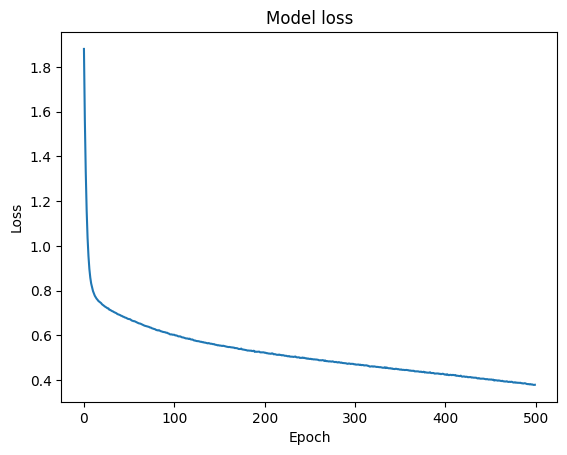

In [31]:
model = initialize_model()

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_test, y_test),
                    epochs=500,
                    batch_size=16,
                    verbose=0)
plot_history(history)

😱 Ama durun... test setini kullanırsak hile yapmış olmaz mıyız? Evet, oluruz. Ama yine sabırlı olun. ***Derin Öğrenme - Optimize Ediciler, Kayıp, Uydurma*** bölümünde, bunu önlemek için ***Doğrulama Seti*** adını verdiğimiz şeyi kullanacağız!

🧘🏻‍♀️ Şimdilik, sonraki sorulara geçelim!

❓ **Ağı değerlendirme**: <span style="color:blue">eğitim seti</span> ve <span style="color:orange">test seti</span> üzerindeki kayıp ve doğruluk değerlerini grafik olarak gösterin. Bu konuda ne söyleyebilirsiniz? ❓ 

In [32]:
def plot_loss_accuracy(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

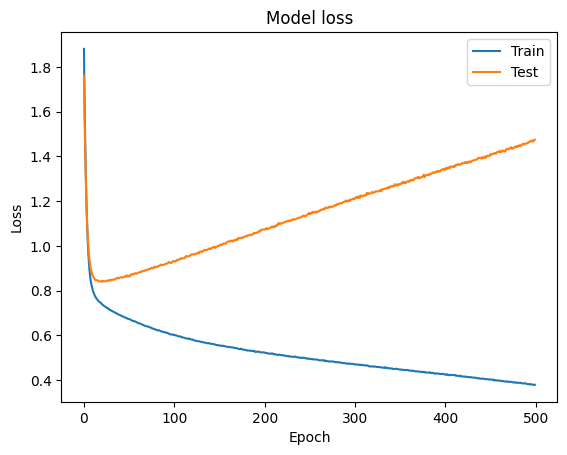

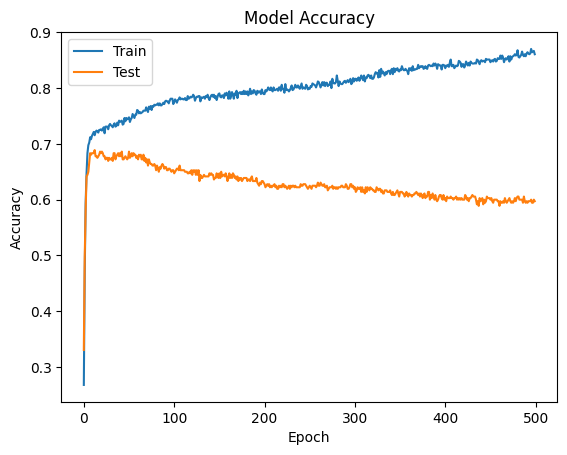

In [33]:
plot_loss_accuracy(history)

Convergence: modelin loss'u giderek azalır ve iyileşmeler yavaşlar.
Overfitting: training performansı iyileşmeye devam ederken validation/test performansı kötüleşir.
İyi model seçimi: training metriğine tek başına bakılmaz; validation/test performansı izlenirç

🤔 Derin Öğrenme modelimiz neden bu kadar kolay aşırı uyum sağlıyor?

😳 Düşünün, sinir ağımız sadece 8 özellik içeren bir veri kümesinden basit bir sınıflandırma görevi için ~800 parametre öğrenmek zorunda! Üstelik, uyum sağlamak için toplamda sadece ~800 veri noktamız var! Model, eğitim kümesindeki her noktanın tam sınıfını neredeyse “öğrenebilir”. 

Buna karşılık, basit bir Lojistik Regresyon, bu blob veri kümesinin kalıplarını yakalamak için sadece 9 parametreyi öğrenmek zorunda kalırdı! 

😏 Derin öğrenme etkileyici bir kavramdır, ancak basit makine öğrenimi görevleri için açıkça aşırı ve gereksiz bir seçenek olabilir!

⭐️ Aşağıdakiler için son derece yararlı olacaktır:
- 📸 Görüntü işleme
- 💹 Zaman serileri
- 🗣 Doğal dil işleme

---

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki göreve geçin!